<a href="https://colab.research.google.com/github/tanyasri1405/machine-learning/blob/skill-ml/experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [1]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [13]:
df = pd.read_csv("titanic.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (891, 15)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
df.columns = df.columns.str.strip()

print("Columns after cleaning:")
print(df.columns.tolist())

Columns after cleaning:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [15]:
if 'Survived' not in df.columns:
    print("ERROR: 'Survived' column was not found.")
    print("Available columns are:")
    print(df.columns.tolist())
else:
    print("Target column 'Survived' found successfully!")

ERROR: 'Survived' column was not found.
Available columns are:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [16]:
columns_to_remove = [
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
]

df = df.drop(
    columns=columns_to_remove,
    errors='ignore'
)

print("Columns after removing unnecessary columns:")
print(df.columns.tolist())

Columns after removing unnecessary columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [17]:
for col in df.columns:

    if pd.api.types.is_numeric_dtype(df[col]):

        df[col] = df[col].fillna(df[col].median())

    else:

        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully!")

print("\nRemaining missing values:")
print(df.isnull().sum())

Missing values handled successfully!

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [18]:
categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("\nEncoding completed!")

print("\nEncoded dataset:")
display(df_encoded.head())

Categorical columns:
['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']

Encoding completed!

Encoded dataset:


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,...,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,22.0,1,0,7.2500,True,False,True,False,...,False,False,True,False,False,False,False,False,True,False
1,1,1,38.0,1,0,71.2833,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,True,False,False,...,True,False,True,False,False,False,False,False,True,True
3,1,1,35.0,1,0,53.1000,False,False,False,False,...,True,False,True,False,False,False,False,False,True,True
4,0,3,35.0,0,0,8.0500,True,True,True,False,...,False,False,True,False,False,False,False,False,True,False


In [19]:
df_encoded = df_encoded.astype(int)

print("All columns are now numeric.")
print(df_encoded.dtypes)

All columns are now numeric.
survived                   int64
pclass                     int64
age                        int64
sibsp                      int64
parch                      int64
fare                       int64
adult_male                 int64
alone                      int64
sex_male                   int64
embarked_Q                 int64
embarked_S                 int64
class_Second               int64
class_Third                int64
who_man                    int64
who_woman                  int64
deck_B                     int64
deck_C                     int64
deck_D                     int64
deck_E                     int64
deck_F                     int64
deck_G                     int64
embark_town_Queenstown     int64
embark_town_Southampton    int64
alive_yes                  int64
dtype: object


In [21]:
print(df_encoded.columns.tolist())

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'embark_town_Queenstown', 'embark_town_Southampton', 'alive_yes']


In [23]:
print("Available columns in your dataset:")
print(df_encoded.columns.tolist())

Available columns in your dataset:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'embark_town_Queenstown', 'embark_town_Southampton', 'alive_yes']


In [25]:
# Show all columns
print("Columns in the dataset:")
print(df_encoded.columns.tolist())

# Find the survival/target column automatically
target_col = None

for col in df_encoded.columns:
    if 'surviv' in col.lower():
        target_col = col
        break

if target_col is None:
    print("\nNo survival column found.")
    print("Please check the column names printed above.")
else:
    print("\nTarget column found:", target_col)

    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]

    print("\nX shape:", X.shape)
    print("y shape:", y.shape)

    print("\nFeatures:")
    print(X.columns.tolist())

Columns in the dataset:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'embark_town_Queenstown', 'embark_town_Southampton', 'alive_yes']

Target column found: survived

X shape: (891, 23)
y shape: (891,)

Features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'class_Second', 'class_Third', 'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'embark_town_Queenstown', 'embark_town_Southampton', 'alive_yes']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 23)
Testing data: (179, 23)


In [27]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [28]:
y_pred = model.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



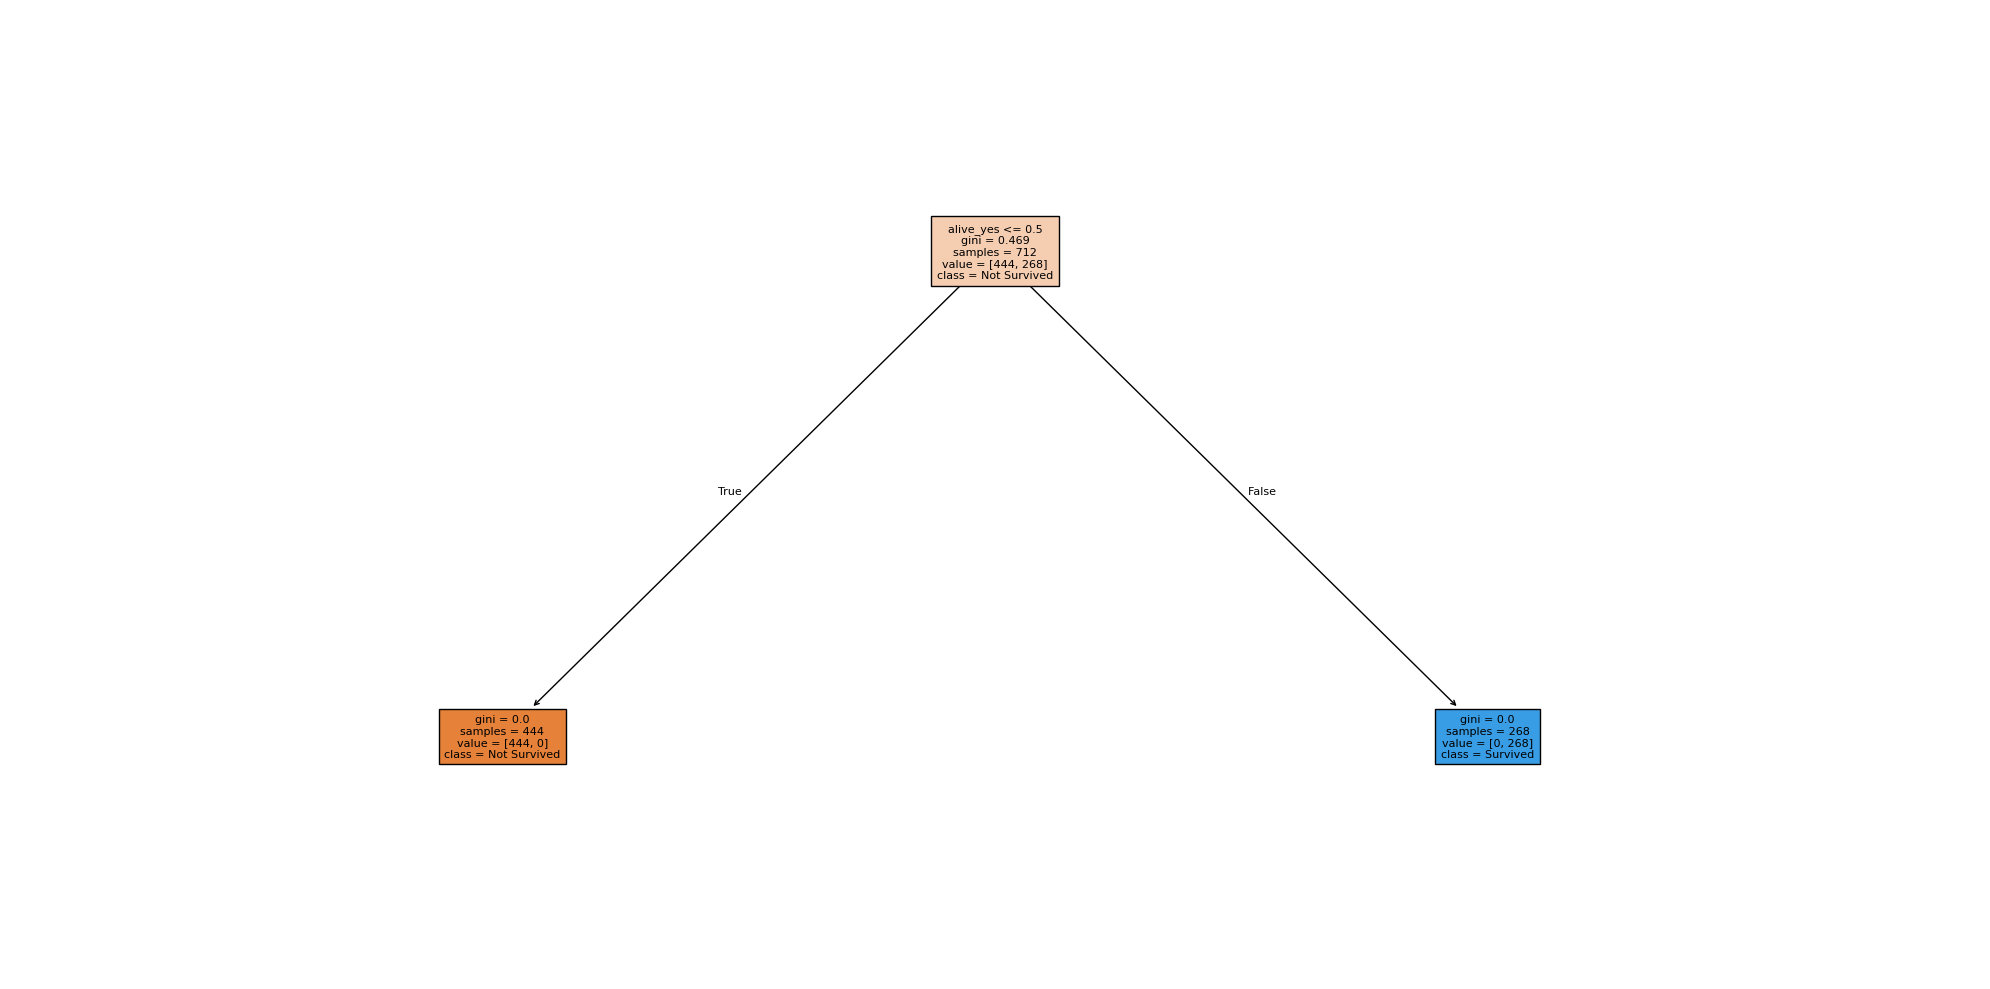

In [29]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [31]:
y_pred_rf = rf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest OOB Score:")
print(round(rf.oob_score_, 4))

print("\nRandom Forest Test Accuracy:")
print(round(test_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest OOB Score:
1.0

Random Forest Test Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



In [32]:
print("Feature Importances:\n")

for name, importance in sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"{name}: {importance:.4f}")

Feature Importances:

alive_yes: 0.6092
adult_male: 0.0700
who_man: 0.0695
sex_male: 0.0381
who_woman: 0.0380
fare: 0.0376
age: 0.0305
pclass: 0.0223
class_Third: 0.0205
sibsp: 0.0137
deck_C: 0.0101
parch: 0.0093
embarked_S: 0.0051
embark_town_Southampton: 0.0050
class_Second: 0.0046
alone: 0.0041
deck_B: 0.0040
deck_E: 0.0031
deck_D: 0.0016
embark_town_Queenstown: 0.0014
embarked_Q: 0.0014
deck_G: 0.0006
deck_F: 0.0003


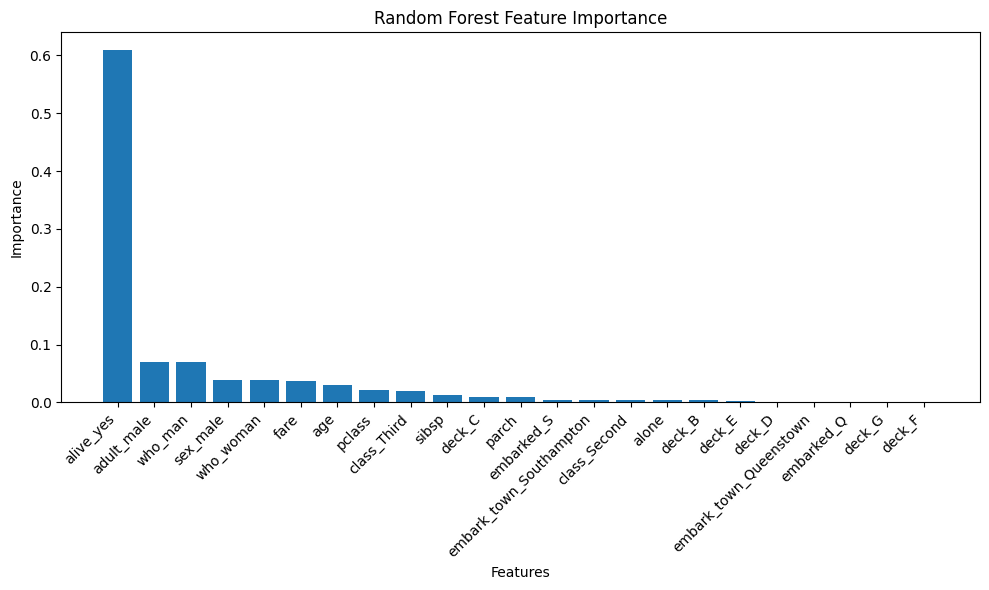

In [33]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()